In [280]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.tree import DecisionTreeRegressor

In [281]:
train_df = pd.read_csv('listings_train.csv')
test_df = pd.read_csv('listings_test_features.csv')

test_df


,id,name,host_id,host_name,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_group,neighbourhood,latitude,...,last_review,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license
0,1.136690e+18,chill flat,81356851,Sylwia,1,t,f,NaN,Barnet,51.626248,...,2025-07-20,0.30,5.00,5.00,5.00,4.75,5.00,5.00,5.00,NaN
1,6.919139e+06,2014 VW Camper called Viv,7724775,Jenna,1,t,t,NaN,Lewisham,51.428070,...,2024-08-19,0.09,5.00,5.00,4.89,5.00,5.00,5.00,5.00,NaN
2,1.376724e+18,Elegant City Stay steps to Oxford Street,594523926,Fabio,12,t,t,NaN,Camden,51.520461,...,2025-07-02,0.68,3.33,4.00,3.67,4.00,3.67,4.00,3.33,NaN
3,1.365046e+18,Indigo Flats Chic Apartment 2 West End,29024847,Sarah,96,t,t,NaN,Westminster,51.513179,...,2025-07-14,0.46,5.00,5.00,5.00,5.00,5.00,5.00,5.00,NaN
4,1.385436e+18,Holloway 3-BR flat w. Private Patio near Camden,661844715,Anna,49,t,t,NaN,Islington,51.551530,...,2025-09-08,3.28,4.71,4.64,4.57,4.57,4.71,4.79,4.79,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8194,2.170603e+07,Chic Getaway In Chelsea,158024537,Lucy,2,t,t,NaN,Kensington and Chelsea,51.492100,...,2025-08-03,0.54,4.76,4.92,4.86,4.96,4.98,4.96,4.69,NaN
8195,7.572697e+17,Bright Bedroom - 7 mins to Buckingham Palace,20366937,Jon,1,t,t,NaN,Wandsworth,51.460048,...,2024-09-02,0.50,4.41,4.41,3.94,4.76,4.76,4.94,4.29,NaN
8196,1.113756e+18,Comely Deluxe South Central London Apartment,12291293,Jay,61,t,t,NaN,Southwark,51.485010,...,2025-09-09,3.46,4.61,4.76,4.78,4.66,4.78,4.08,4.59,NaN
8197,1.330432e+18,Baker Street Stylish Getaway 2BR,202552824,Mohammed,27,t,t,NaN,Westminster,51.519840,...,2025-07-27,0.88,4.00,4.00,3.33,3.67,4.00,4.33,4.00,NaN


# EDA

Q0: The is supervised regression becasue we have a known continuouse target(ie. nightly rate for an Airbnb) in the training data 

In [282]:
#Q1: Data Quality 
training = pd.read_csv('listings_train.csv')
testing = pd.read_csv('listings_test_features.csv')

print("Training set:", training.shape[0], "rows" , training.shape[1], "cols")
print("Testing set:", testing.shape[0], "rows" , testing.shape[1], "cols")

only_in_training = set(training.columns) - set(testing.columns)
only_in_testing = set(testing.columns) - set(training.columns)
print("columns only in the training set: " , only_in_training)
print("columns only in the testing set: " , only_in_testing)


Training set: 42234 rows 36 cols
Testing set: 8199 rows 35 cols
columns only in the training set:  {'price'}
columns only in the testing set:  set()


In [283]:
#Q1: missing values in training: 
print("Missing fields from each listing in training data")
training.isnull().sum()[training.isnull().sum() > 0].sort_values(ascending=False)


Missing fields from each listing in training data


license                        42234
neighbourhood_group            42234
review_scores_value             9137
review_scores_location          9137
review_scores_checkin           9137
review_scores_communication     9136
review_scores_cleanliness       9136
review_scores_accuracy          9136
review_scores_rating            9135
reviews_per_month               9135
last_review                     9135
beds                              80
bedrooms                          47
bathrooms                         42
host_name                         18
host_total_listings_count         16
host_identity_verified            16
host_has_profile_pic              16
dtype: int64

In [284]:
#Q1: missing values in testing:
print("Missing fields from each listing in testing data") 
testing.isnull().sum()[testing.isnull().sum() > 0].sort_values(ascending=False)

Missing fields from each listing in testing data


neighbourhood_group    8199
license                8199
dtype: int64

In [285]:
#Q1: Usable Rows: 
print("Full training rows: ", training.dropna().shape[0]/training.shape[0])
print("Full testing rows: ", testing.dropna().shape[0]/testing.shape[0])

print("There are no listings in either data sets that have a complete row")

Full training rows:  0.0
Full testing rows:  0.0
There are no listings in either data sets that have a complete row


In [286]:
#Figuring out what columns to remove
print("Percentage of listings that are missing the specified field (ie every listing in training lacks a license and neighborhood group:")
print("review_scores_value, review_scores_location, review_scores_checkin, review_scores_communication, review_scores_cleanliness,review_scores_accuracy,\n last_review,reviews_per_month, and review_scores_rating are missing from about 21% of the listings   ")
(training.isnull().sum() / len(training) * 100).sort_values(ascending=False)


Percentage of listings that are missing the specified field (ie every listing in training lacks a license and neighborhood group:
review_scores_value, review_scores_location, review_scores_checkin, review_scores_communication, review_scores_cleanliness,review_scores_accuracy,
 last_review,reviews_per_month, and review_scores_rating are missing from about 21% of the listings   


license                           100.000000
neighbourhood_group               100.000000
review_scores_value                21.634228
review_scores_location             21.634228
review_scores_checkin              21.634228
review_scores_communication        21.631861
review_scores_cleanliness          21.631861
review_scores_accuracy             21.631861
last_review                        21.629493
reviews_per_month                  21.629493
review_scores_rating               21.629493
beds                                0.189421
bedrooms                            0.111285
bathrooms                           0.099446
host_name                           0.042620
host_identity_verified              0.037884
host_has_profile_pic                0.037884
host_total_listings_count           0.037884
availability_60                     0.000000
number_of_reviews                   0.000000
availability_90                     0.000000
id                                  0.000000
availabili

In [287]:
print(" Percentage of listings that are missing the specified field (ie every listing in testing lacks a license and neighborhood group")
(testing.isnull().sum() / len(testing) * 100).sort_values(ascending=False)

 Percentage of listings that are missing the specified field (ie every listing in testing lacks a license and neighborhood group


license                           100.0
neighbourhood_group               100.0
reviews_per_month                   0.0
amenities                           0.0
availability_30                     0.0
availability_60                     0.0
availability_90                     0.0
number_of_reviews                   0.0
last_review                         0.0
review_scores_rating                0.0
bedrooms                            0.0
review_scores_accuracy              0.0
review_scores_cleanliness           0.0
review_scores_checkin               0.0
review_scores_communication         0.0
review_scores_location              0.0
review_scores_value                 0.0
beds                                0.0
id                                  0.0
name                                0.0
accommodates                        0.0
number_of_reviews_ltm               0.0
availability_365                    0.0
calculated_host_listings_count      0.0
minimum_nights                      0.0


# Q2: Distribution: 

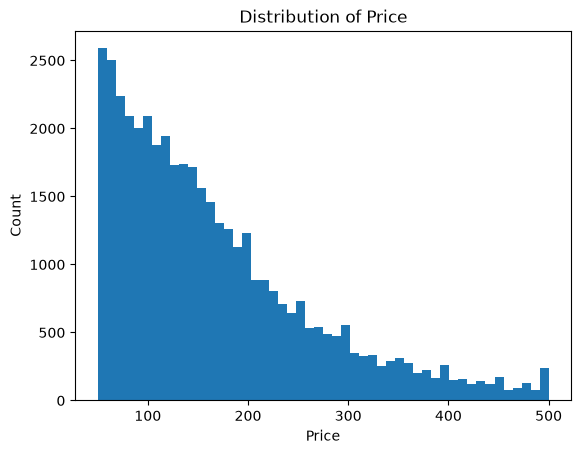

In [288]:
plt.hist(training['price'],bins=50)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

           

The seems to be more of a right skewed distribution, with a little over 2500 listings that fall under $100. As the price increases the number of listings decreasesss(ie, there more less expensive listings then expensive listings) towards the far right of the graph we see a spike in listings, that is most likley due to the price cut off on the graph forcing the remaining airbnbs to reside in the same line. 

MEDIAN PRICE: 

In [289]:
price = training['price'].median()
print ("Median price of Airbnb listing $", price)

Median price of Airbnb listing $ 141.0


Most features dont seem to be normally distributed. Longitute and latitude seem to be the most semetrical.
Id and host-id dont really have a meaningfull distribution given that these are not determining factors on nightly rate.
Count based features ( ie. minimum_nights, number_of_reviews, bedrooms, etc.) are right skewed similar to price. 
Review score columns are left skewed, clustering near 5 stars
Availability columns are bimodal, with most listings either rarely or almost always available.


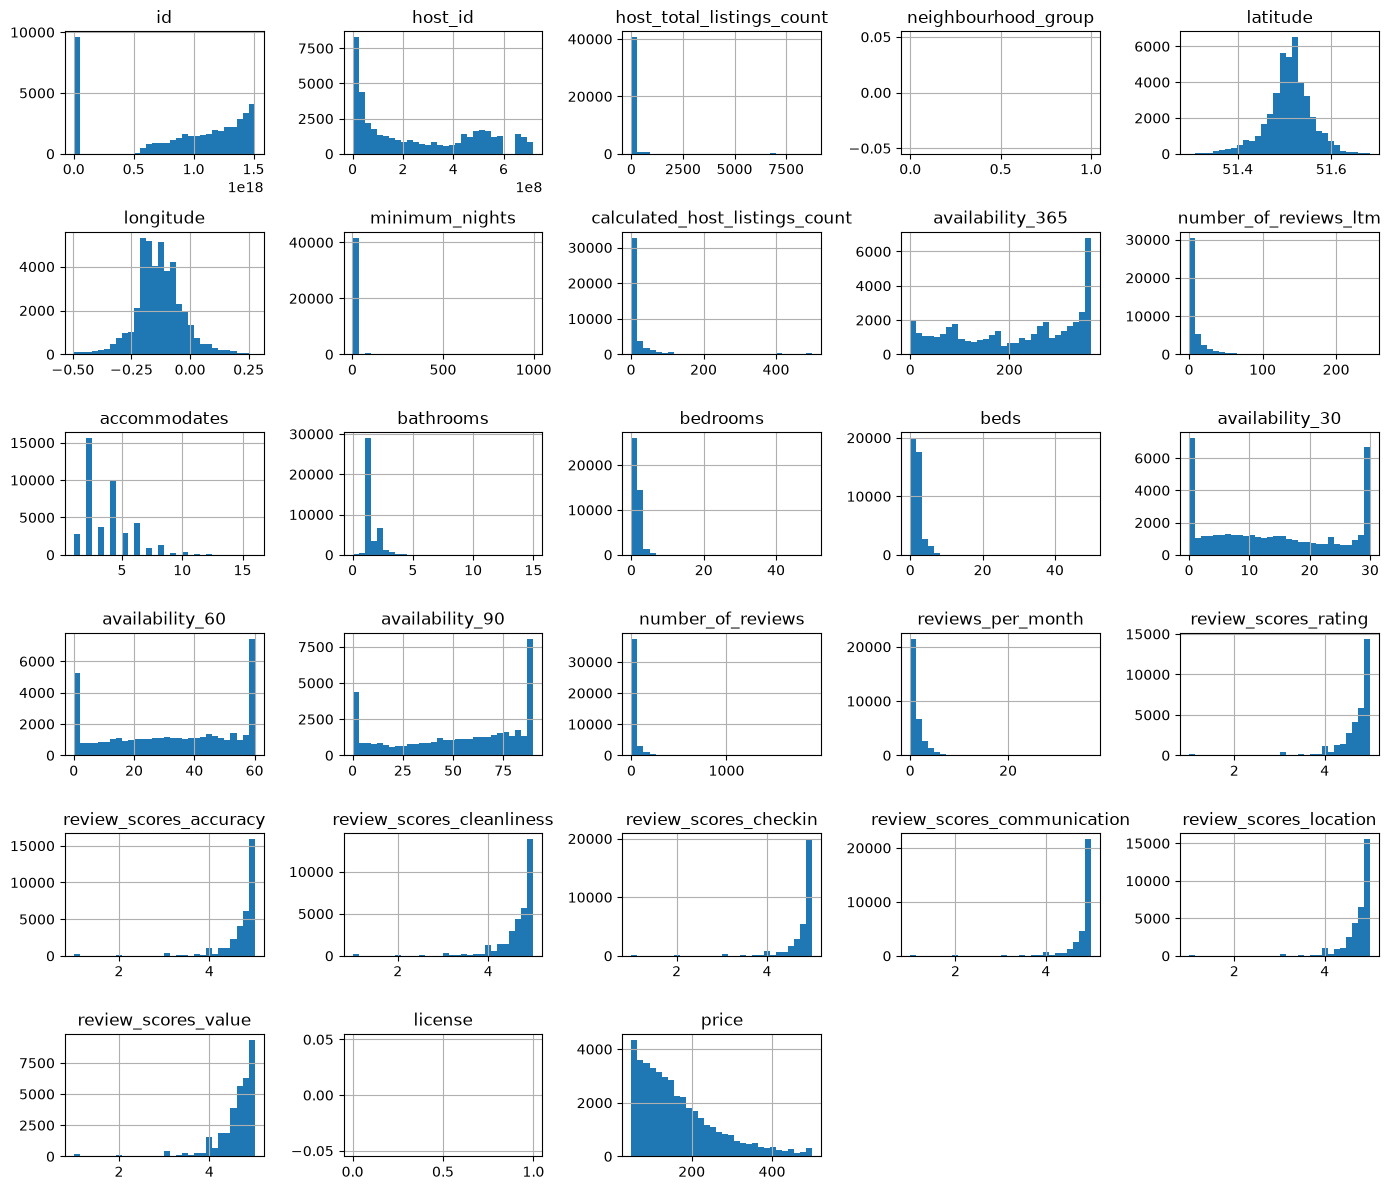

In [290]:
training.hist(figsize=(14,12), bins=30)
plt.tight_layout()
print("Most features dont seem to be normally distributed. Longitute and latitude seem to be the most semetrical.")
print("Id and host-id dont really have a meaningfull distribution given that these are not determining factors on nightly rate.")
print("Count based features ( ie. minimum_nights, number_of_reviews, bedrooms, etc.) are right skewed similar to price. ")
print("Review score columns are left skewed, clustering near 5 stars")
print("Availability columns are bimodal, with most listings either rarely or almost always available.")
plt.show()

# How many unique values does each column have?

In [291]:
cols = training.select_dtypes(include='object').columns
for c in cols:
    print(c, ": ", training[c].nunique(), " unique values")

print(" 1) Columns room_type, and neighborhood will be one-hot encoded becasue they have a very small number of unique values and actually should contribute heavily to the nightly rate.")
print(" 2) Columns like name and host_name will just be discarded becasue they dont contribute anything to the price prediction and one-hot encoding them would produce a largley unnecessary amount of new columns.")
print(" 3) Host verification,last_review, and profile pic will also be discarded becasue they dont provide anything for price prediction")
print(" 4) Amenities will be filtered by a handfull of prioirtie amenities(ie. washer/ dryer in unit, dishwasher, wifi, allows pets, pool, backyard ) and turned into individual boolean flag columns")

name :  41118  unique values
host_name :  9090  unique values
host_has_profile_pic :  2  unique values
host_identity_verified :  2  unique values
neighbourhood :  33  unique values
room_type :  4  unique values
amenities :  38642  unique values
last_review :  1660  unique values
 1) Columns room_type, and neighborhood will be one-hot encoded becasue they have a very small number of unique values and actually should contribute heavily to the nightly rate.
 2) Columns like name and host_name will just be discarded becasue they dont contribute anything to the price prediction and one-hot encoding them would produce a largley unnecessary amount of new columns.
 3) Host verification,last_review, and profile pic will also be discarded becasue they dont provide anything for price prediction
 4) Amenities will be filtered by a handfull of prioirtie amenities(ie. washer/ dryer in unit, dishwasher, wifi, allows pets, pool, backyard ) and turned into individual boolean flag columns


/var/folders/t8/6tbq6mls08vcjj89czt65k680000gn/T/ipykernel_4975/3168214869.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = training.select_dtypes(include='object').columns


# relationship between the price and minimum_nights columns

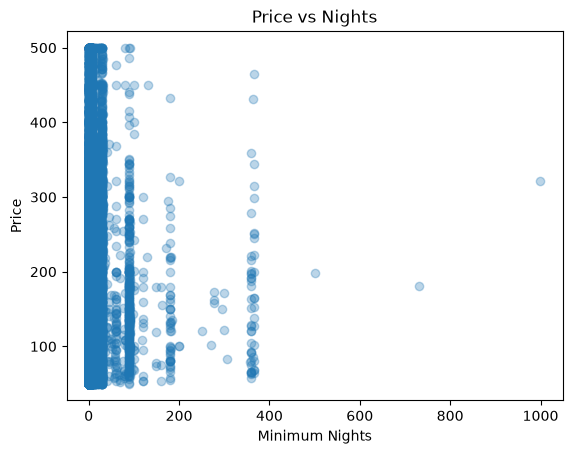

Correlation: 0.03233606382661914
There seems to be no relationship between minimum nights and price in this data set


In [292]:
plt.scatter(training['minimum_nights'], training['price'], alpha=0.3)
plt.title("Price vs Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Price")
plt.show()
print("Correlation:", training['price'].corr(training['minimum_nights']))
print("There seems to be no relationship between minimum nights and price in this data set")

# Data cleansing / Feature Engineering

# Model preparation

In [293]:
#Droping unhelpfull columns
dropped_cols = ['host_id', 'license', 'neighbourhood_group', 'name', 'host_name', 'last_review']
training = training.drop(columns=dropped_cols)
testing = testing.drop(columns=dropped_cols)


# Handling Amenities 

In [294]:
training['has_dishwasher'] = training['amenities'].str.contains('Dishwasher', case=False, na=False)
training['has_backyard'] = training['amenities'].str.contains('Backyard', case=False, na=False)
training['has_dryer'] = training['amenities'].str.contains('Free Dryer', case=False, na=False)
training['has_washer'] = training['amenities'].str.contains(r'\bWasher\b', case=False, na=False, regex=True)
training['has_pets'] = training['amenities'].str.contains('Pets allowed', case=False, na=False)
training['has_wifi'] = training['amenities'].str.contains('Wifi', case=False, na=False)
training['has_pool'] = training['amenities'].str.contains('Pool', case=False, na=False)

testing['has_dishwasher'] = testing['amenities'].str.contains('Dishwasher', case=False, na=False)
testing['has_backyard'] = testing['amenities'].str.contains('Backyard', case=False, na=False)
testing['has_dryer'] = testing['amenities'].str.contains('Free Dryer', case=False, na=False)
testing['has_washer'] = testing['amenities'].str.contains(r'\bWasher\b', case=False, na=False, regex=True)
testing['has_pets'] = testing['amenities'].str.contains('Pets allowed', case=False, na=False)
testing['has_wifi'] = testing['amenities'].str.contains('Wifi', case=False, na=False)
testing['has_pool'] = testing['amenities'].str.contains('Pool', case=False, na=False)

training = training.drop(columns=['amenities'])
testing = testing.drop(columns=['amenities'])

In [295]:
print("Total listings:", len(training))
print("has_dryer:", training['has_dryer'].sum())
print("has_washer:", training['has_washer'].sum())
print("has_wifi:", training['has_wifi'].sum())

Total listings: 42234
has_dryer: 6379
has_washer: 36569
has_wifi: 41225


In [296]:
review_cols = ['reviews_per_month', 'review_scores_rating', 'review_scores_accuracy','review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']

for col in review_cols:
    training[col] = training[col].fillna(0)
    testing[col] = testing[col].fillna(0)

In [297]:
physical_cols = ['beds', 'bedrooms', 'bathrooms', 'host_total_listings_count']

for col in physical_cols:
    training[col] = training[col].fillna(training[col].median())
    testing[col] = testing[col].fillna(training[col].median())


In [298]:
for col in ['host_identity_verified', 'host_has_profile_pic']:
    mode_val = training[col].mode()[0]
    training[col] = training[col].fillna(mode_val)
    testing[col] = testing[col].fillna(mode_val)

In [299]:
training = pd.get_dummies(training, columns=['room_type', 'neighbourhood'])
testing = pd.get_dummies(testing, columns=['room_type', 'neighbourhood'])

print(training.shape)
print(testing.shape)

(42234, 71)
(8199, 70)


In [300]:
train_cols = set(training.columns)
test_cols = set(testing.columns)

print("In training but not testing:", train_cols - test_cols)
print("In testing but not training:", test_cols - train_cols)

In training but not testing: {'price'}
In testing but not training: set()


In [301]:
for col in ['host_has_profile_pic', 'host_identity_verified']:
    training[col] = training[col].map({'t': 1, 'f': 0})
    testing[col] = testing[col].map({'t': 1, 'f': 0})

# Model

# Linear Regression Model

In [303]:
X = training.drop(columns=['id','price'])
y = training['price']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val,pred))

print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 65.73736933077626


# CART

In [315]:
cart_model = DecisionTreeRegressor(random_state=42, max_depth=12,min_samples_leaf=20)
cart_model.fit(X_train,y_train)

cart_pred = cart_model.predict(X_val)
cart_rmse = np.sqrt(mean_squared_error(y_val,cart_pred))

print("Decision Tree RMSE:", cart_rmse)

Decision Tree RMSE: 64.47142025524279


# Predictions

In [316]:
test_ids = testing['id']
X_test = testing.drop(columns=['id'])


In [318]:
predictions = cart_model.predict(X_test)

In [320]:
output = pd.DataFrame({'price': predictions})
output.to_csv('A4_predictions_MaiLi.csv', index=False)